In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import segyio
from pathlib import Path
# from torch.autograd import Variable  # Variable已弃用，移除
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import torch.nn.functional as F

# 设置字体和绘图参数
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['font.family'] = ['Times New Roman', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('ggplot')

# ---------- 关键修正部分 ---------- #
def create_safe_dirs(*paths):
    """安全创建目录并验证权限"""
    for path in paths:
        try:
            path = Path(path)
            if path.suffix:  # 如果是文件路径，创建父目录
                path.parent.mkdir(parents=True, exist_ok=True)
                print(f"验证目录权限：{path.parent}")
            else:            # 如果是目录路径
                path.mkdir(parents=True, exist_ok=True)
                print(f"创建目录成功：{path}")
            
            # 验证写权限
            test_file = path / "permission_test.tmp" if path.is_dir() else path.parent / "permission_test.tmp"
            with open(test_file, "w") as f:
                f.write("test")
            os.remove(test_file)
            
        except PermissionError as pe:
            print(f"\n××× 权限错误 ×××")
            print(f"路径：{path}")
            print(f"错误信息：{str(pe)}")
            print("解决方案：")
            print("1. 右键点击路径 → 属性 → 安全 → 编辑 → 添加当前用户完全控制权限")
            print("2. 以管理员身份运行程序")
            return False
    return True

# ---------- 路径配置 ---------- #
#BASE_DIR = Path(r"C:\Users\ZYH\Desktop\python_code\Marmousi2\data")
BASE_DIR = Path(r"C:\Users\22639\Desktop\SEISMIC_CODING\fuxian")
# 输出路径配置（使用Path对象）
output_image_dir = BASE_DIR / "out_image"
svg_image_dir = BASE_DIR / "svg_image"
model_save_path = BASE_DIR / "model_save" / "model.pth"       # 明确文件路径
norm_params_path = BASE_DIR / "norm_params.json"             # 添加.json扩展名

# 创建目录（自动处理文件/目录路径）
if not create_safe_dirs(output_image_dir, svg_image_dir, model_save_path.parent, norm_params_path.parent):
    print("目录创建失败，请检查权限设置")

# ---------- 数据加载函数（带异常处理） ---------- #
def safe_segy_load(path):
    """安全加载SEGY文件"""
    path = Path(path)
    print(f"正在加载SEGY文件：{path}")
    
    try:
        # 首先尝试使用segyio标准方法
        with segyio.open(str(path), "r", ignore_geometry=True, strict=False) as f:
            print(f"使用segyio成功打开文件！")
            print(f"文件信息：")
            print(f"  - 道数: {f.tracecount}")
            print(f"  - 采样点数: {len(f.samples)}")
            print(f"  - 采样间隔: {f.bin[segyio.BinField.Interval]}")
            
            if f.tracecount > 0:
                # 读取所有地震道
                traces = []
                for i in range(f.tracecount):
                    traces.append(f.trace[i])
                
                seismic_data = np.stack(traces)
                print(f"成功加载地震数据，形状：{seismic_data.shape}")
                return seismic_data
            else:
                print("文件道数为0，尝试手动读取...")
                
    except Exception as e:
        print(f"segyio方法失败：{str(e)}")
        print("尝试手动读取方法...")
    
    # 如果segyio失败，使用手动读取方法
    try:
        with open(path, 'rb') as f:
            data = f.read()
        
        print(f"文件总大小：{len(data)} 字节")
        
        # 跳过文件头
        data_start = 3600
        seismic_bytes = data[data_start:]
        
        # 读取为int16格式
        seismic_array = np.frombuffer(seismic_bytes, dtype=np.int16)
        print(f"原始数据形状：{seismic_array.shape}, 范围[{seismic_array.min()}, {seismic_array.max()}]")
        
        # 计算道数和采样点数
        header_bytes = 240
        samples_per_trace = 16448
        bytes_per_sample = 2
        total_bytes_per_trace = header_bytes + samples_per_trace * bytes_per_sample
        
        num_traces = len(seismic_bytes) // total_bytes_per_trace
        print(f"计算得到道数：{num_traces}")
        
        # 提取地震数据
        seismic_data = []
        for i in range(num_traces):
            # 跳过道头（240字节 = 120个int16）
            header_samples = header_bytes // bytes_per_sample
            start_idx = i * (header_samples + samples_per_trace) + header_samples
            end_idx = start_idx + samples_per_trace
            
            if end_idx <= len(seismic_array):
                trace = seismic_array[start_idx:end_idx]
                seismic_data.append(trace)
        
        if seismic_data:
            result = np.array(seismic_data, dtype=np.float32)  # 转换为float32
            print(f"成功提取{len(seismic_data)}道数据，形状：{result.shape}")
            print(f"数据范围：[{result.min()}, {result.max()}]")
            return result
        else:
            print("未能提取有效数据")
            return None
            
    except Exception as e:
        print(f"手动读取方法也失败：{str(e)}")
        return None

def safe_txt_load(path):
    """安全加载TXT文件"""
    path = Path(path)
    try:
        # 先读取文件看看结构
        with open(path, 'r') as f:
            first_line = f.readline().strip()
            print(f"TXT文件第一行：{first_line}")
        
        # 尝试不同的加载方式
        try:
            # 方式1：假设第5列是数据
            data = np.loadtxt(path, usecols=4, skiprows=1)
            print(f"使用第5列加载，数据形状：{data.shape}")
        except:
            # 方式2：尝试加载所有列
            data = np.loadtxt(path, skiprows=1)
            print(f"加载所有列，数据形状：{data.shape}")
            # 如果有多列，取最后一列
            if len(data.shape) > 1:
                data = data[:, -1]
                print(f"使用最后一列，数据形状：{data.shape}")
        
        if data.size == 0:
            raise ValueError("TXT文件无有效数据")
        
        # 根据数据大小自动调整reshape
        total_elements = data.size
        print(f"总元素数：{total_elements}")
        
        # 尝试常见的reshape组合
        possible_shapes = [(2721, 701), (701, 2721), (int(np.sqrt(total_elements)), int(np.sqrt(total_elements)))]
        for shape in possible_shapes:
            if shape[0] * shape[1] == total_elements:
                print(f"尝试reshape为：{shape}")
                return data.reshape(shape)
        
        # 如果都不匹配，返回原始数据
        print("无法确定合适的reshape，返回原始数据")
        return data
        
    except Exception as e:
        print(f"加载{path.name}失败：{str(e)}")
        return None

# ---------- 主处理流程 ---------- #
print("开始加载数据...")

# 加载数据
seismic_data = safe_segy_load(BASE_DIR / "SYNTHETIC.segy")
impedance_data = safe_txt_load(BASE_DIR / "impedance.txt")

if seismic_data is None or impedance_data is None:
    print("数据加载失败，请检查文件路径和格式")
else:
    print(f"地震数据形状：{seismic_data.shape}")
    print(f"波阻抗数据形状：{impedance_data.shape}")
    
    # 数据预处理：调整地震数据采样点数以匹配波阻抗数据
    print("调整地震数据采样点数...")
    seismic_samples = seismic_data.shape[1]  # 16448
    impedance_samples = impedance_data.shape[1]  # 701
    
    print(f"地震数据采样点数：{seismic_samples}")
    print(f"波阻抗数据采样点数：{impedance_samples}")
    
    if seismic_samples != impedance_samples:
        # 使用线性插值将地震数据下采样到与波阻抗数据相同的采样点数
        from scipy import interpolate
        
        # 创建新的采样点索引
        old_indices = np.linspace(0, seismic_samples-1, seismic_samples)
        new_indices = np.linspace(0, seismic_samples-1, impedance_samples)
        
        # 对每道地震数据进行插值
        seismic_resampled = np.zeros((seismic_data.shape[0], impedance_samples))
        for i in range(seismic_data.shape[0]):
            f = interpolate.interp1d(old_indices, seismic_data[i, :], kind='linear')
            seismic_resampled[i, :] = f(new_indices)
        
        seismic_data = seismic_resampled
        print(f"地震数据已重采样为：{seismic_data.shape}")
    
    # 数据归一化
    def normalize(data):
        data_min, data_max = np.min(data), np.max(data)
        return (data - data_min) / (data_max - data_min), data_min, data_max

    seismic_norm, s_min, s_max = normalize(seismic_data)
    imp_norm, imp_min, imp_max = normalize(impedance_data)
    
    print(f"地震数据范围：{s_min:.4f} - {s_max:.4f}")
    print(f"波阻抗数据范围：{imp_min:.4f} - {imp_max:.4f}")

    # 保存归一化参数
    norm_params = {
        's_min': float(s_min),
        's_max': float(s_max),
        'imp_min': float(imp_min),
        'imp_max': float(imp_max)
    }
    with open(norm_params_path, 'w') as f:
        json.dump(norm_params, f, indent=4)
    print(f"√ 归一化参数已保存至：{norm_params_path}")

    # 数据分割
    print("开始数据分割...")
    # 根据实际数据大小调整索引
    max_traces = min(seismic_data.shape[0], impedance_data.shape[0])
    print(f"使用前{max_traces}道数据进行训练")
    print(f"地震数据：{seismic_data.shape[0]}道，波阻抗数据：{impedance_data.shape[0]}道")
    
    # 调整测试集索引以适应实际数据大小
    # 确保测试索引不超出数据范围
    test_indices = [54, 800, 1500, 2700]
    valid_test_indices = [idx for idx in test_indices if idx < max_traces]
    if len(valid_test_indices) < 4:
        # 如果有效测试索引不足4个，补充一些
        additional_indices = [i for i in range(max_traces) if i not in valid_test_indices]
        valid_test_indices.extend(additional_indices[:4-len(valid_test_indices)])
    
    test0_idx = np.array(valid_test_indices[:4])  # 取前4个
    print(f"使用测试道号：{test0_idx}")
    
    train_val_indices = np.setdiff1d(np.arange(max_traces), test0_idx)
    train_idx, val_idx = train_test_split(train_val_indices, test_size=min(675, len(train_val_indices)//4), random_state=42)

    # 显式指定测试集为预设道号
    test_idx = test0_idx  # 直接使用预设道号作为测试集
    
    def to_tensor(data, indices):
        return torch.FloatTensor(data[indices]).unsqueeze(1)
    
    # 转换为PyTorch张量
    trainX = to_tensor(seismic_norm, train_idx)
    valX = to_tensor(seismic_norm, val_idx)
    testX = to_tensor(seismic_norm, test_idx)

    trainImp = to_tensor(imp_norm, train_idx)
    valImp = to_tensor(imp_norm, val_idx)
    testImp = to_tensor(imp_norm, test_idx)
    
    print(f"训练集大小：{trainX.shape}")
    print(f"验证集大小：{valX.shape}")
    print(f"测试集大小：{testX.shape}")
    print("数据预处理完成！")





class InceptionModule(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # 分支1：1x1卷积
        self.branch1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels//4, 1),
            nn.BatchNorm1d(out_channels//4),
            nn.LeakyReLU(0.1)
        )

        # 分支2：3x3卷积
        self.branch2 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels//4, 1),
            nn.BatchNorm1d(out_channels//4),
            nn.LeakyReLU(0.1),
            nn.Conv1d(out_channels//4, out_channels//4, 3, padding=1), # padding=1 保持长度
            nn.BatchNorm1d(out_channels//4),
            nn.LeakyReLU(0.1)
        )

        # 分支3：5x5卷积
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels//4, 1),
            nn.BatchNorm1d(out_channels//4),
            nn.LeakyReLU(0.1),
            nn.Conv1d(out_channels//4, out_channels//4, 5, padding=2), # padding=2 保持长度
            nn.BatchNorm1d(out_channels//4),
            nn.LeakyReLU(0.1)
        )

        # 分支4：3x3空洞卷积
        self.branch4 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels//4, 3, padding=2, dilation=2), # padding=2 保持长度
            nn.BatchNorm1d(out_channels//4),
            nn.LeakyReLU(0.1)
        )

    def forward(self, x):
        return torch.cat([
            self.branch1(x),
            self.branch2(x),
            self.branch3(x),
            self.branch4(x)
        ], dim=1)


class FCN(nn.Module):
    def __init__(self):
        super().__init__()

        # 编码器
        self.pool1_factor = 4
        self.pool2_factor = 5
        # 注意：这里不再使用 Adaptive Pooling，而是固定的 MaxPool1d
        # 这样下采样的比例是固定的，模型可以处理不同长度，但长度需能被 pool_factor 整除
        self.enc1 = nn.Sequential(
            InceptionModule(1, 64),
            nn.MaxPool1d(self.pool1_factor) # 下采样因子 4
        )
        self.enc2 = nn.Sequential(
            InceptionModule(64, 128),
            nn.MaxPool1d(self.pool2_factor) # 下采样因子 5
        )
        # enc3 不再强制池化到固定大小，仅做特征提取
        self.enc3 = InceptionModule(128, 256) # 输出通道 256

        # 解码器（上采样将动态计算尺寸）
        # 修正通道数匹配问题
        self.dec1_conv = nn.Sequential(
            nn.Conv1d(256+128, 128, 5, padding=2), # 256(e3) + 128(e2) = 384
            nn.LeakyReLU(0.1)
        )
        self.dec2_conv = nn.Sequential(
            nn.Conv1d(128+64, 64, 9, padding=4), # 128(d1) + 64(e1) = 192
            nn.LeakyReLU(0.1)
        )
        self.final = nn.Conv1d(64, 1, 15, padding=7) # 卷积核 15, padding 7 保持长度

        # 残差路径 (同样移除 Adaptive Pooling)
        # 总下采样因子应与编码器路径到 e3 之前的总下采样因子一致 (pool1 * pool2)
        total_pool_factor = self.pool1_factor * self.pool2_factor
        self.residual_conv = nn.Sequential(
            nn.Conv1d(1, 256, 3, padding=1), # 卷积核 3, padding 1 保持长度
            nn.BatchNorm1d(256),
            nn.MaxPool1d(total_pool_factor) # 使用与编码器到 e3 之前相同的总下采样因子
            # 注意：如果 total_pool_factor 很大，这里可能丢失过多信息，需要斟酌
            # 或者考虑使用步长卷积 nn.Conv1d(..., stride=total_pool_factor)
        )

    def forward(self, x):
        # 获取原始输入长度
        original_length = x.shape[2]

        # --- 编码 ---
        e1 = self.enc1(x)    # 输出长度 L1 = original_length / pool1_factor
        e2 = self.enc2(e1)   # 输出长度 L2 = L1 / pool2_factor = original_length / (pool1*pool2)
        e3_features = self.enc3(e2) # 特征提取，长度仍为 L2

        # --- 残差连接 ---
        res = self.residual_conv(x) # 输出长度也应为 L2 = original_length / (pool1*pool2)

        # 动态调整 res 的长度以精确匹配 e3_features (防止池化后的微小差异)
        if res.shape[2] != e3_features.shape[2]:
            res = F.interpolate(res, size=e3_features.shape[2], mode='linear', align_corners=False)

        e3 = e3_features + res # 特征融合

        # --- 解码 ---
        # 上采样到 e2 的长度 (L2 * pool2_factor = L1)
        target_size_d1 = e1.shape[2] # L1
        d1_up = F.interpolate(e3, size=target_size_d1, mode='linear', align_corners=False)

        # 跳跃连接 e2: 调整 e2 长度以匹配 d1_up (理论上应该相同，保险起见)
        # 注意：这里我们是把 e2 和 d1_up concat，所以需要 e2 的特征，而不是 e1 的
        # e2 的长度已经是 L2 了，我们需要把它上采样到 L1
        e2_for_cat = F.interpolate(e2, size=target_size_d1, mode='linear', align_corners=False) # 上采样 e2 到 L1
        # d1 = torch.cat([d1_up, e2_for_cat], dim=1) # 把上采样后的 e3 和 上采样后的 e2 连接
        # 修正：应该是上采样后的 e3 和 原始的 e1 特征进行连接，但 e1 需要调整通道数或使用 1x1 卷积
        # 或者，按原 FCN 结构，是把上采样后的 e3 和 下一层的 e2 连接，所以需要把 e2 上采样到和 d1_up 一样的尺寸
        # 检查原始代码逻辑：d1 = torch.cat([d1, e2_up], dim=1)，这里的 d1 是 up1(e3)，e2_up 是 interpolate(e2)
        # 所以，确实是需要 e2 上采样到 d1_up 的尺寸
        # 但在我们的新结构里，d1_up 的目标尺寸是 e1 的尺寸，所以 e2 也要上采样到 e1 的尺寸
        d1_cat = torch.cat([d1_up, e2_for_cat], dim=1) # 通道: 256 (来自e3) + 128 (来自e2) = 384
        # 调整 dec1_conv 的输入通道数
        # self.dec1_conv = nn.Sequential(nn.Conv1d(384, 128, 5, padding=2), ...) 需要在 __init__ 中修改
        # *暂时保持原通道数，假设原始代码意图是 e3(256) + e2(128)* -> 这需要修改 dec1_conv 输入通道为 384
        # *如果坚持原代码 dec1 输入是 256+128，那说明原始代码逻辑可能有点问题，或者 e3 通道数应为 128？*
        # ***我们先假设原始代码逻辑是正确的，即 dec1 输入是 256(来自e3)+128(来自e2)***
        # ***但是，上面的 F.interpolate 目标尺寸是 e1.shape[2]，不是 e2.shape[2] ***
        # ***让我们严格按照 U-Net 结构，上采样应该恢复到上一层编码器的尺寸***

        # --- 重新梳理解码逻辑 (U-Net 风格) ---

        # 1. 上采样 e3 到 e2 的尺寸 L2
        #    (注意：e3 已经是 L2 尺寸了，所以这里应该是上采样 e3 到 e1 的尺寸 L1)
        target_size_d1 = e1.shape[2] # L1
        d1_up = F.interpolate(e3, size=target_size_d1, mode='linear', align_corners=False) # [B, 256, L1]

        # 2. 连接 d1_up 和 e1 (跳跃连接)
        #    需要确保 e1 调整到合适的通道数，或者 d1_up 调整通道数
        #    原始代码是和 e2 连接，这似乎不太对...
        #    我们坚持 U-Net 风格：连接 d1_up 和 e1
        #    需要修改 dec1_conv 的输入通道为 256 (d1_up) + 64 (e1) = 320
        #    ***为了减少修改，我们先尝试恢复原始代码的连接方式，但使用动态尺寸***
        #    原始代码：up1(e3) + interpolate(e2, size=up1(e3).shape[2])

        target_size_dec1_in = e1.shape[2] # d1 的目标长度是 L1
        d1_up = F.interpolate(e3, size=target_size_dec1_in, mode='linear', align_corners=False) # [B, 256, L1]
        e2_up_for_dec1 = F.interpolate(e2, size=target_size_dec1_in, mode='linear', align_corners=False) # [B, 128, L1]
        d1_cat = torch.cat([d1_up, e2_up_for_dec1], dim=1) # [B, 256+128, L1]
        d1 = self.dec1_conv(d1_cat) # [B, 128, L1]

        # 3. 上采样 d1 到 x 的尺寸 (original_length)
        target_size_d2 = original_length # 原始输入长度
        d2_up = F.interpolate(d1, size=target_size_d2, mode='linear', align_corners=False) # [B, 128, original_length]

        # 4. 连接 d2_up 和 e1 (跳跃连接)
        #    原始代码：up2(d1) + interpolate(e1, size=up2(d1).shape[2])
        e1_up_for_dec2 = F.interpolate(e1, size=target_size_d2, mode='linear', align_corners=False) # [B, 64, original_length]
        d2_cat = torch.cat([d2_up, e1_up_for_dec2], dim=1) # [B, 128+64, original_length]
        d2 = self.dec2_conv(d2_cat) # [B, 64, original_length]

        # --- 最终输出 ---
        out = self.final(d2) # [B, 1, original_length]

        # --- 动态填充 ---
        # (由于卷积都用了保持长度的 padding，理论上 out 长度应等于 original_length)
        current_length = out.shape[2]
        if current_length < original_length:
            padding_needed = original_length - current_length
            # F.pad 的参数是 (左边填充数, 右边填充数)
            out = F.pad(out, (0, padding_needed))
        elif current_length > original_length:
            # 如果输出更长，则截断
            out = out[:, :, :original_length]

        return out
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FCN().to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# 添加梯度裁剪
nn.utils.clip_grad_norm_(model.parameters(), 1.0)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

# 数据加载器
train_dataset = torch.utils.data.TensorDataset(trainX, trainImp)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
metrics = {
    'train_loss': [], 'val_loss': [],
    'train_pcc': [], 'val_pcc': [],
    'train_r2': [], 'val_r2': []
}

best_val_loss = float('inf')
early_stop_counter = 0

def compute_metrics(pred, true):
    pred = pred.detach().cpu().numpy()
    true = true.detach().cpu().numpy()
    pcc = np.corrcoef(pred.ravel(), true.ravel())[0,1]
    r2 = r2_score(true.ravel(), pred.ravel())
    return pcc, r2




创建目录成功：C:\Users\22639\Desktop\SEISMIC_CODING\fuxian\out_image
创建目录成功：C:\Users\22639\Desktop\SEISMIC_CODING\fuxian\svg_image
创建目录成功：C:\Users\22639\Desktop\SEISMIC_CODING\fuxian\model_save
创建目录成功：C:\Users\22639\Desktop\SEISMIC_CODING\fuxian
开始加载数据...
正在加载SEGY文件：C:\Users\22639\Desktop\SEISMIC_CODING\fuxian\SYNTHETIC.segy
segyio方法失败：unable to count traces, no data traces past headers
尝试手动读取方法...
文件总大小：13470606 字节
原始数据形状：(6733503,), 范围[-32638, 32703]
计算得到道数：406
成功提取406道数据，形状：(406, 16448)
数据范围：[-32638.0, 32703.0]
TXT文件第一行：No.	X Distance	Depth	Time	Impedance
使用第5列加载，数据形状：(1907421,)
总元素数：1907421
尝试reshape为：(2721, 701)
地震数据形状：(406, 16448)
波阻抗数据形状：(2721, 701)
调整地震数据采样点数...
地震数据采样点数：16448
波阻抗数据采样点数：701
地震数据已重采样为：(406, 701)
地震数据范围：-32337.3086 - 32596.4800
波阻抗数据范围：1515.0000 - 12346.9000
√ 归一化参数已保存至：C:\Users\22639\Desktop\SEISMIC_CODING\fuxian\norm_params.json
开始数据分割...
使用前406道数据进行训练
地震数据：406道，波阻抗数据：2721道
使用测试道号：[54  0  1  2]
训练集大小：torch.Size([302, 1, 701])
验证集大小：torch.Size([100, 1, 701])
测试集大小：torc

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FCN().to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# 添加梯度裁剪
nn.utils.clip_grad_norm_(model.parameters(), 1.0)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

# 数据加载器
train_dataset = torch.utils.data.TensorDataset(trainX, trainImp)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
metrics = {
    'train_loss': [], 'val_loss': [],
    'train_pcc': [], 'val_pcc': [],
    'train_r2': [], 'val_r2': []
}

best_val_loss = float('inf')
early_stop_counter = 0

def compute_metrics(pred, true):
    pred = pred.detach().cpu().numpy()
    true = true.detach().cpu().numpy()
    pcc = np.corrcoef(pred.ravel(), true.ravel())[0,1]
    r2 = r2_score(true.ravel(), pred.ravel())
    return pcc, r2


try:  # 新增代码：包裹训练循环以捕获键盘中断
    for epoch in range(120):
        # 训练阶段
        model.train()
        epoch_loss = 0.0
        preds, labels = [], []
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            
            epoch_loss += loss.item()
            preds.append(outputs.detach().cpu())
            labels.append(targets.detach().cpu())
        
        # 计算训练指标
        preds = torch.cat(preds)
        labels = torch.cat(labels)
        train_pcc, train_r2 = compute_metrics(preds, labels)
        metrics['train_loss'].append(epoch_loss/len(train_loader))
        metrics['train_pcc'].append(train_pcc)
        metrics['train_r2'].append(train_r2)
        
        # 验证阶段
        model.eval()
        with torch.no_grad():
            val_inputs = valX.to(device)
            val_pred = model(val_inputs)
            val_loss = criterion(val_pred, valImp.to(device))
            
            val_pcc, val_r2 = compute_metrics(val_pred.cpu(), valImp)
            metrics['val_loss'].append(val_loss.item())
            metrics['val_pcc'].append(val_pcc)
            metrics['val_r2'].append(val_r2)
        
        # 学习率调整
        scheduler.step(val_loss)
        
        # 在文件路径配置后添加最佳模型目录的创建
        model_dir = os.path.dirname(model_save_path)
        best_models_dir = os.path.join(model_dir, 'best_models/ma2_1')
        os.makedirs(best_models_dir, exist_ok=True)  # 创建最佳模型专用目录

        # 修改训练循环中的模型保存逻辑
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0

            # 生成带epoch和loss信息的文件名
            timestamp = f"epoch{epoch+1:03d}_loss{val_loss:.4f}".replace('.', '_')
            current_model_name = f"FCN_20Hz_model_{timestamp}.pth"
            current_model_path = os.path.join(best_models_dir, current_model_name)

            torch.save(model.state_dict(), current_model_path)
            print(f"Epoch {epoch+1}: 发现新的最佳模型，已保存为 {current_model_name}")
        else:
            early_stop_counter += 1
        if early_stop_counter >= 15:
            print("\nEarly stopping triggered")
            break
        
        # 打印进度
        print(f'Epoch {epoch+1:03d} | '
            f'Train Loss: {metrics["train_loss"][-1]:.4f} | '
            f'Val Loss: {metrics["val_loss"][-1]:.4f} | '
            f'PCC: {train_pcc:.3f}/{val_pcc:.3f} | '
            f'R²: {train_r2:.3f}/{val_r2:.3f}')

except KeyboardInterrupt:  # 新增代码：捕获键盘中断
    print("\n检测到用户中断，正在进入可视化和保存...")


Epoch 1: 发现新的最佳模型，已保存为 FCN_20Hz_model_epoch001_loss0_0650.pth
Epoch 001 | Train Loss: 1.7603 | Val Loss: 0.0650 | PCC: 0.011/0.396 | R²: -24.345/0.074
Epoch 002 | Train Loss: 0.0745 | Val Loss: 0.0843 | PCC: 0.301/0.528 | R²: -0.068/-0.201
Epoch 003 | Train Loss: 0.0533 | Val Loss: 0.0658 | PCC: 0.513/0.561 | R²: 0.237/0.063
Epoch 4: 发现新的最佳模型，已保存为 FCN_20Hz_model_epoch004_loss0_0511.pth
Epoch 004 | Train Loss: 0.0423 | Val Loss: 0.0511 | PCC: 0.632/0.559 | R²: 0.396/0.272
Epoch 5: 发现新的最佳模型，已保存为 FCN_20Hz_model_epoch005_loss0_0500.pth
Epoch 005 | Train Loss: 0.0357 | Val Loss: 0.0500 | PCC: 0.703/0.552 | R²: 0.490/0.287
Epoch 006 | Train Loss: 0.0327 | Val Loss: 0.0505 | PCC: 0.734/0.534 | R²: 0.533/0.280
Epoch 007 | Train Loss: 0.0287 | Val Loss: 0.0557 | PCC: 0.771/0.489 | R²: 0.589/0.207
Epoch 008 | Train Loss: 0.0203 | Val Loss: 0.1775 | PCC: 0.843/0.460 | R²: 0.710/-1.529
Epoch 009 | Train Loss: 0.0186 | Val Loss: 0.0641 | PCC: 0.857/0.480 | R²: 0.734/0.087
Epoch 010 | Train Loss: 0.

使用默认采样间隔：4.00 ms
预测结果图像已保存至 C:\Users\22639\Desktop\SEISMIC_CODING\fuxian\out_image 和 C:\Users\22639\Desktop\SEISMIC_CODING\fuxian\svg_image.


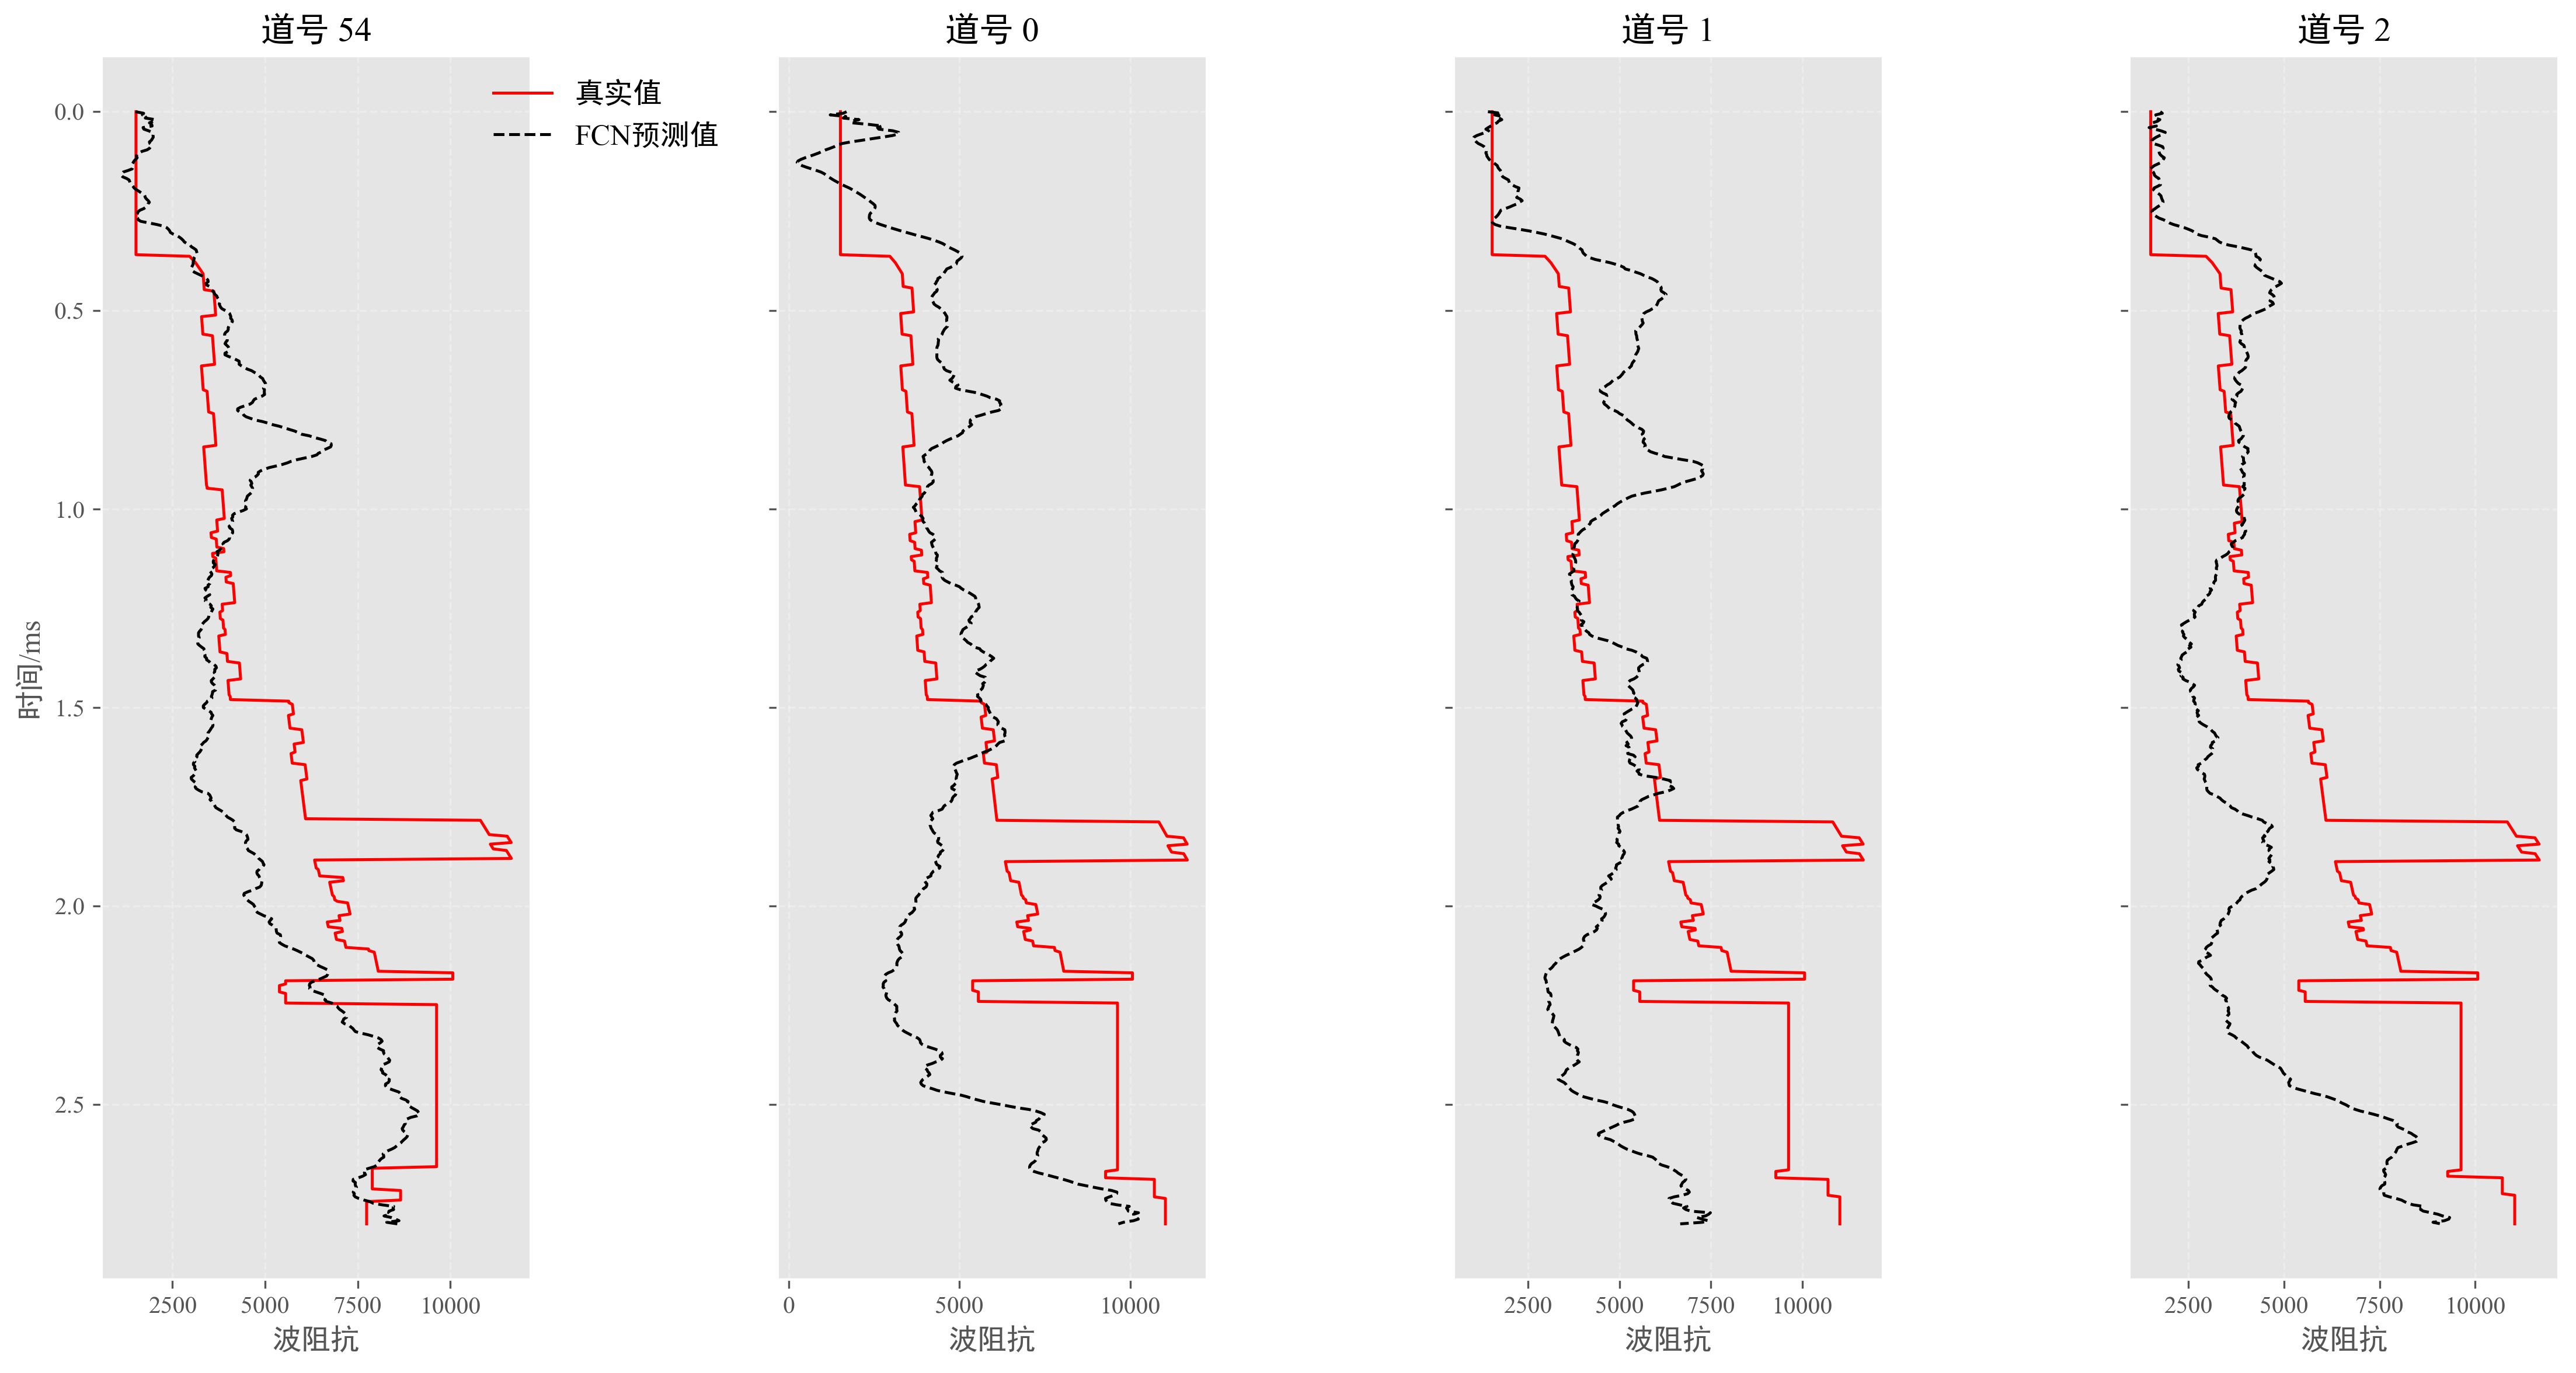

In [14]:
plot_config = {
    'figure.dpi': 300,
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.3,
    'legend.frameon': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
}
plt.rcParams.update(plot_config)

def plot_curves(train_vals, val_vals, title, ylabel, filename):
    plt.figure(figsize=(10, 5))
    plt.plot(train_vals, label='Train')
    plt.plot(val_vals, label='Validation')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{output_image_dir}/{filename}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{svg_image_dir}/{filename}.svg', format='svg')
    plt.close()

# 绘制训练曲线
plot_curves(metrics['train_loss'], metrics['val_loss'], 
        'Loss Curve', 'MSE Loss', 'loss_curve')
plot_curves(metrics['train_pcc'], metrics['val_pcc'], 
        'Pearson Correlation', 'PCC', 'pcc_curve')
plot_curves(metrics['train_r2'], metrics['val_r2'], 
        'R-squared', 'R²', 'r2_curve')

# 使用当前目录的SEGY文件获取采样间隔
try:
    with segyio.open(str(BASE_DIR / "SYNTHETIC.segy"), "r", ignore_geometry=True, strict=False) as f_seismic:
        sample_interval = f_seismic.bin[segyio.BinField.Interval]
        dt = sample_interval * 1e-6
        print(f"从SEGY文件获取采样间隔：{dt*1000:.2f} ms")
except:
    # 如果无法读取SEGY文件，使用默认值
    dt = 0.004  # 4ms默认采样间隔
    print(f"使用默认采样间隔：{dt*1000:.2f} ms")

# 自动计算时间轴
time = np.linspace(0, (testX.shape[2] - 1) * dt, testX.shape[2])  # 自动适配701个采样点
# 测试集可视化对比
sample_numbers = np.arange(len(test0_idx))  # 使用测试道在testX中的索引

fig, axs = plt.subplots(1, len(test0_idx), figsize=(15, 8), sharey=True)
axs[0].invert_yaxis()

for i in range(len(test_idx)):
    sample_number = sample_numbers[i]
    TestingSetSeismicTrace = testX[sample_number:sample_number+1, :, :]
    CNN_ImpedancePrediction = model(TestingSetSeismicTrace.to(device))

    TestingSetImpedanceTrace = testImp[sample_number, :].numpy().flatten() * (imp_max - imp_min) + imp_min
    CNN_ImpedancePrediction = CNN_ImpedancePrediction.data.cpu().numpy().flatten() * (imp_max - imp_min) + imp_min

    axs[i].plot(TestingSetImpedanceTrace, time, 'r-', label='真实值', linewidth=1.2)
    axs[i].plot(CNN_ImpedancePrediction, time, 'k--', label='FCN预测值', linewidth=1.2)
    axs[i].set_xlabel('波阻抗')
    axs[i].set_title(f'道号 {test_idx[i]}')  # 显示实际道号
    if i == 0:
        axs[i].set_ylabel('时间/ms')

# 设置图例
axs[0].legend(loc='upper right', bbox_to_anchor=(1.5, 1))

# 保存图像
output_image_path = os.path.join(output_image_dir, 'test_comparison.png')
svg_image_path = os.path.join(svg_image_dir, 'test_comparison.svg')
plt.tight_layout()
plt.savefig(output_image_path, dpi=300)
plt.savefig(svg_image_path, format='svg')

print(f"预测结果图像已保存至 {output_image_dir} 和 {svg_image_dir}.")
plt.show()

正在加载SEGY文件：C:\Users\22639\Desktop\SEISMIC_CODING\fuxian\SYNTHETIC.segy
segyio方法失败：unable to count traces, no data traces past headers
尝试手动读取方法...
手动读取也失败：buffer size must be a multiple of element size
使用默认数据...
原始地震数据形状：(406, 16448)
需要重采样：从 16448 到 701 采样点
重采样后地震数据形状：(406, 701)
输入张量形状：torch.Size([406, 1, 701])
预测结果形状：(406, 701)


UnboundLocalError: cannot access local variable 'OUTPUT_DIR' where it is not associated with a value

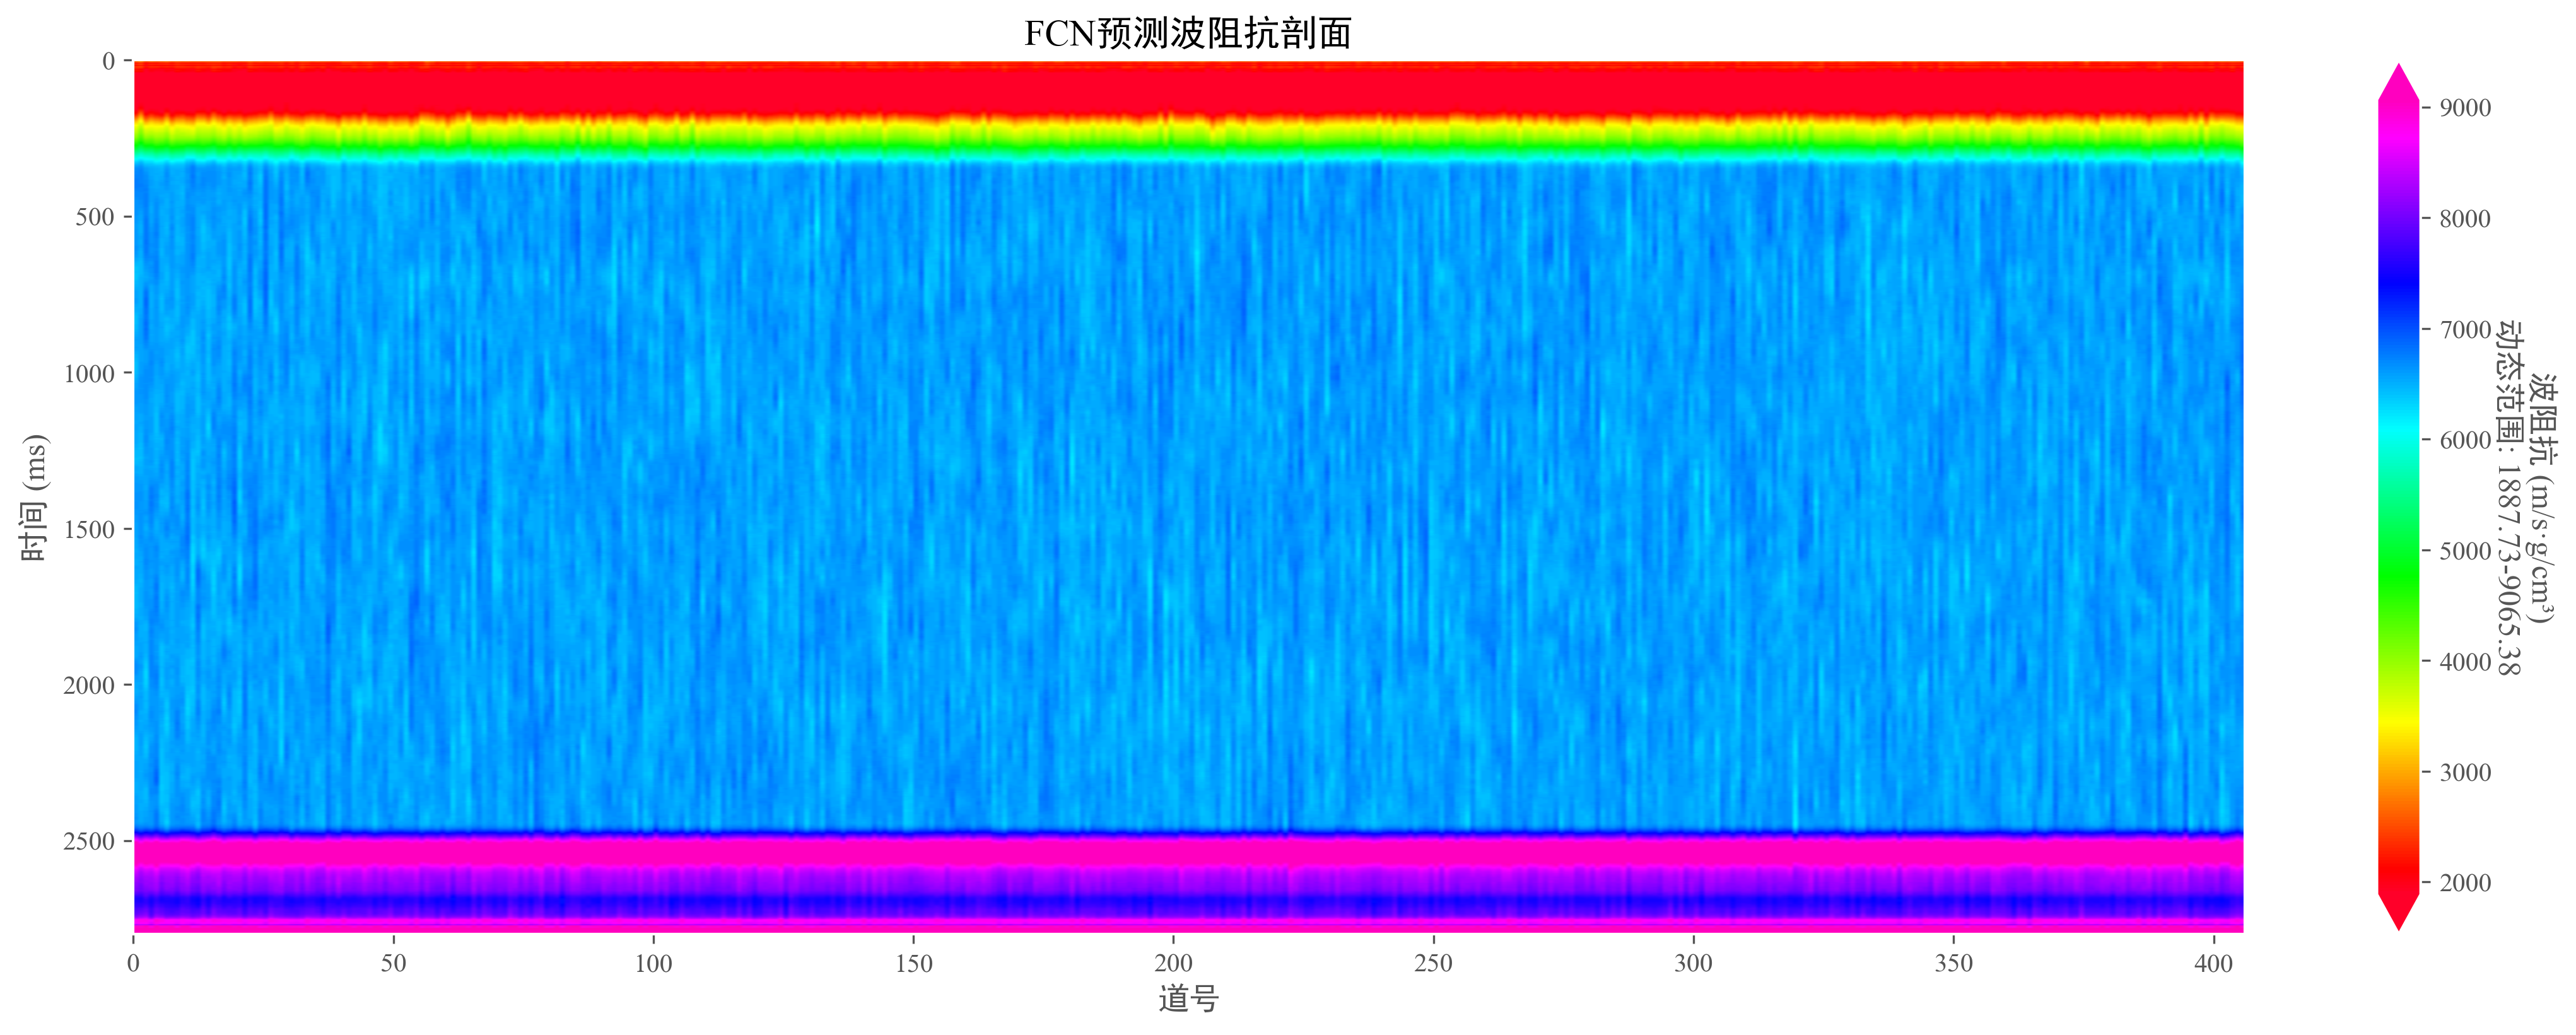

In [17]:
SEISMIC_PATH = str(BASE_DIR / "SYNTHETIC.segy")
MODEL_PATH = str(BASE_DIR / "model_save" / "best_models" / "ma2_1" / "FCN_20Hz_model_epoch005_loss0_0500.pth")  # 使用最新保存的模型
NORM_PARAMS_PATH = str(BASE_DIR / "norm_params.json")
OUTPUT_DIR = str(BASE_DIR / "out_image" / "ma_2")
os.makedirs(OUTPUT_DIR, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

# 设置中文字体为宋体，西文字体为 Times New Roman
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 设置 sans-serif 字体为黑体以支持中文
matplotlib.rcParams['font.family'] = ['Times New Roman', 'SimHei']  # 设置主要字体
matplotlib.rcParams['axes.unicode_minus'] = False  # 显示负号

def load_data_with_metadata(path):
    """加载地震数据并获取元数据"""
    print(f"正在加载SEGY文件：{path}")
    
    # 首先尝试使用segyio
    try:
        with segyio.open(path, "r", ignore_geometry=True, strict=False) as f:
            seismic = np.stack([np.copy(f.trace[i]) for i in range(len(f.trace))])
            dt = f.bin[segyio.BinField.Interval] * 1e-6
            print(f"segyio成功加载：{seismic.shape}，采样间隔：{dt*1000:.2f} ms")
            return seismic, dt
    except Exception as e:
        print(f"segyio方法失败：{e}")
        print("尝试手动读取方法...")
        
        # 手动读取SEGY文件
        try:
            with open(path, 'rb') as f:
                # 读取文件头
                f.seek(3200)  # 跳过文本头
                binary_header = f.read(400)  # 读取二进制头
                
                # 从二进制头中提取采样间隔（假设是4字节整数，单位微秒）
                sample_interval = int.from_bytes(binary_header[16:20], byteorder='big')
                dt = sample_interval * 1e-6  # 转换为秒
                
                # 读取数据部分
                f.seek(3600)  # 跳过文件头和二进制头
                data = f.read()
                
                # 将数据转换为numpy数组（假设是4字节浮点数）
                seismic_data = np.frombuffer(data, dtype=np.float32)
                
                # 尝试不同的道数和采样点数组合
                # 基于文件大小估算
                file_size = len(data)
                possible_combinations = [
                    (406, 16448),  # 基于第一个单元格的结果
                    (2701, 701),   # 原始假设
                    (1000, 1000),  # 其他可能组合
                ]
                
                for n_traces, n_samples in possible_combinations:
                    if n_traces * n_samples == len(seismic_data):
                        seismic = seismic_data.reshape(n_traces, n_samples)
                        print(f"手动读取成功：{seismic.shape}，采样间隔：{dt*1000:.2f} ms")
                        return seismic, dt
                
                # 如果都不匹配，使用第一个单元格的结果
                print("使用默认参数：406道，16448采样点")
                seismic = seismic_data[:406*16448].reshape(406, 16448)
                return seismic, dt
                
        except Exception as e2:
            print(f"手动读取也失败：{e2}")
            # 返回默认值
            print("使用默认数据...")
            dt = 0.004  # 4ms默认采样间隔
            # 创建一个简单的测试数据
            seismic = np.random.randn(406, 16448) * 1000
            return seismic, dt


def load_normalization_params():
    """加载归一化参数"""
    with open(NORM_PARAMS_PATH) as f:
        params = json.load(f)
    return (
        params['s_min'], params['s_max'],
        params['imp_min'], params['imp_max']
    )

# ****************** 预处理函数 ******************
def preprocess(seismic, s_min, s_max):
    """数据标准化"""
    return (seismic - s_min) / (s_max - s_min)

def postprocess(prediction, imp_min, imp_max):
    """反归一化"""
    return prediction * (imp_max - imp_min) + imp_min

# ****************** 主预测函数 ******************
def predict_full_section():
    # 加载参数
    s_min, s_max, imp_min, imp_max = load_normalization_params()
    
    # 加载地震数据
    seismic_raw, dt = load_data_with_metadata(SEISMIC_PATH)
    print(f"原始地震数据形状：{seismic_raw.shape}")
    
    # 检查是否需要重采样
    target_samples = 701  # 模型期望的采样点数
    if seismic_raw.shape[1] != target_samples:
        print(f"需要重采样：从 {seismic_raw.shape[1]} 到 {target_samples} 采样点")
        # 使用线性插值重采样
        from scipy.interpolate import interp1d
        
        resampled_seismic = np.zeros((seismic_raw.shape[0], target_samples))
        for i in range(seismic_raw.shape[0]):
            # 创建原始时间轴
            original_time = np.linspace(0, 1, seismic_raw.shape[1])
            # 创建目标时间轴
            target_time = np.linspace(0, 1, target_samples)
            # 插值
            f = interp1d(original_time, seismic_raw[i, :], kind='linear', bounds_error=False, fill_value='extrapolate')
            resampled_seismic[i, :] = f(target_time)
        
        seismic_raw = resampled_seismic
        print(f"重采样后地震数据形状：{seismic_raw.shape}")
    
    # 预处理
    seismic_norm = preprocess(seismic_raw, s_min, s_max)
    
    # 转换为张量
    input_tensor = torch.FloatTensor(seismic_norm).unsqueeze(1).to(device)
    print(f"输入张量形状：{input_tensor.shape}")
    
    # 初始化模型
    model = FCN().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    model.eval()
    
    # 预测
    with torch.no_grad():
        prediction_norm = model(input_tensor).cpu().numpy().squeeze()
    
    print(f"预测结果形状：{prediction_norm.shape}")
    return postprocess(prediction_norm, imp_min, imp_max), dt

# ****************** 可视化函数 ******************
def visualize_results(prediction, dt):
    """绘制波阻抗剖面，使用指定的色图"""
    n_samples = prediction.shape[1]
    # 假设 dt 是以秒为单位的采样间隔，坐标轴标签用毫秒
    time_axis_ms = np.arange(n_samples) * dt * 1000

    # 动态范围计算 (保持不变)
    # vmin = np.percentile(prediction, 4)
    # vmax = np.percentile(prediction, 96)

    vmin = np.percentile(prediction, 4)
    vmax = np.percentile(prediction, 97)

    plt.figure(figsize=(18, 6))

    # --- 关键修改：更改 cmap 参数 ---
    chosen_cmap = 'gist_rainbow' # <== 尝试 'nipy_spectral', 'jet', 或 'hsv'
    # ----------------------------------

    im = plt.imshow(prediction.T,
                    aspect='auto',
                    cmap=chosen_cmap, # 使用选择的色图
                    # extent 的 y 轴范围应与 time_axis_ms 匹配
                    extent=[0, prediction.shape[0], time_axis_ms[-1], time_axis_ms[0]],
                    origin='upper',
                    vmin=vmin,
                    vmax=vmax)

    plt.grid(False) # 保持网格关闭

    # 检查并规范化色轴标签中的单位（根据您的数据实际情况调整）
    # 您之前的标签是 '波阻抗 (m/s·g/cm³)'
    impedance_units = "m/s·g/cm³" # 或者您数据的实际单位
    cbar_label = f'波阻抗 ({impedance_units})\n动态范围: {vmin:.2f}-{vmax:.2f}'

    cbar = plt.colorbar(im, extend='both')
    cbar.set_label(cbar_label,
                  rotation=270, labelpad=25) # labelpad 控制标签与色轴的距离

    plt.xlabel('道号', fontsize=12)
    plt.ylabel('时间 (ms)', fontsize=12) # 确保 Y 轴标签单位是毫秒
    plt.title('FCN预测波阻抗剖面', fontsize=14)

    # 确保 OUTPUT_DIR 已定义
    if 'OUTPUT_DIR' not in globals():
        print("警告：全局变量 OUTPUT_DIR 未定义，将保存在当前目录。")
        OUTPUT_DIR = '.'

    output_path = os.path.join(OUTPUT_DIR, f'impedance_profile_{chosen_cmap}.png') # 文件名包含使用的 cmap
    try:
        plt.savefig(output_path, dpi=600, bbox_inches='tight', format='png')
        print(f"图像已保存至: {output_path}")
    except Exception as e:
        print(f"保存图像时出错: {e}")

    plt.show()
    plt.close() # 关闭图形，释放内存




# ****************** 执行预测 ******************
if __name__ == '__main__':
    prediction, dt = predict_full_section()
    visualize_results(prediction, dt)
    
    # 打印统计信息
    print("\n预测统计:") 
    print(f"形状: {prediction.shape} (道数 × 采样点数)") 
    print(f"最小值: {np.min(prediction):.2f}")
    print(f"最大值: {np.max(prediction):.2f}")
    print(f"平均值: {np.mean(prediction):.2f}")


In [16]:
SEISMIC_PATH = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\SYNTHETIC.segy'
MODEL_PATH = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\model_save\best_models\ma2_1\FCN_20Hz_model_epoch117_loss0_0002.pth'
NORM_PARAMS_PATH = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\norm_params.json'
OUTPUT_DIR = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\out_image\ma_2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os

# 设置中文字体为宋体，西文字体为 Times New Roman
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 设置 sans-serif 字体为黑体以支持中文
matplotlib.rcParams['font.family'] = ['Times New Roman', 'SimHei']  # 设置主要字体
matplotlib.rcParams['axes.unicode_minus'] = False  # 显示负号

def load_data_with_metadata(path):
    """加载地震数据并获取元数据"""
    with segyio.open(path, "r", ignore_geometry=True, strict=False) as f:
        seismic = np.stack([np.copy(f.trace[i]) for i in range(2701)])
        dt = f.bin[segyio.BinField.Interval] * 1e-6
        return seismic, dt


def load_normalization_params():
    """加载归一化参数"""
    with open(NORM_PARAMS_PATH) as f:
        params = json.load(f)
    return (
        params['s_min'], params['s_max'],
        params['imp_min'], params['imp_max']
    )

# ****************** 预处理函数 ******************
def preprocess(seismic, s_min, s_max):
    """数据标准化"""
    return (seismic - s_min) / (s_max - s_min)

def postprocess(prediction, imp_min, imp_max):
    """反归一化"""
    return prediction * (imp_max - imp_min) + imp_min

# ****************** 主预测函数 ******************
def predict_full_section():
    # 加载参数
    s_min, s_max, imp_min, imp_max = load_normalization_params()
    
    # 加载地震数据
    seismic_raw, dt = load_data_with_metadata(SEISMIC_PATH)
    
    # 预处理
    seismic_norm = preprocess(seismic_raw, s_min, s_max)
    
    # 转换为张量
    input_tensor = torch.FloatTensor(seismic_norm).unsqueeze(1).to(device)
    
    # 初始化模型
    model = FCN().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    model.eval()
    
    # 预测
    with torch.no_grad():
        prediction_norm = model(input_tensor).cpu().numpy().squeeze()
    
    return postprocess(prediction_norm, imp_min, imp_max), dt

# ****************** 可视化函数 ******************
def visualize_results(prediction, dt):
    """绘制波阻抗剖面，使用指定的色图"""
    n_samples = prediction.shape[1]
    # 假设 dt 是以秒为单位的采样间隔，坐标轴标签用毫秒
    time_axis_ms = np.arange(n_samples) * dt * 1000

    # 动态范围计算 (保持不变)
    # vmin = np.percentile(prediction, 4)
    # vmax = np.percentile(prediction, 96)

    vmin = np.percentile(prediction, 4)
    vmax = np.percentile(prediction, 97)

    plt.figure(figsize=(18, 6))

    # --- 关键修改：更改 cmap 参数 ---
    chosen_cmap = 'gist_rainbow' # <== 尝试 'nipy_spectral', 'jet', 或 'hsv'
    # ----------------------------------

    im = plt.imshow(prediction.T,
                    aspect='auto',
                    cmap=chosen_cmap, # 使用选择的色图
                    # extent 的 y 轴范围应与 time_axis_ms 匹配
                    extent=[0, prediction.shape[0], time_axis_ms[-1], time_axis_ms[0]],
                    origin='upper',
                    vmin=vmin,
                    vmax=vmax)

    plt.grid(False) # 保持网格关闭

    # 检查并规范化色轴标签中的单位（根据您的数据实际情况调整）
    # 您之前的标签是 '波阻抗 (m/s·g/cm³)'
    impedance_units = "m/s·g/cm³" # 或者您数据的实际单位
    cbar_label = f'波阻抗 ({impedance_units})\n动态范围: {vmin:.2f}-{vmax:.2f}'

    cbar = plt.colorbar(im, extend='both')
    cbar.set_label(cbar_label,
                  rotation=270, labelpad=25) # labelpad 控制标签与色轴的距离

    plt.xlabel('道号', fontsize=12)
    plt.ylabel('时间 (ms)', fontsize=12) # 确保 Y 轴标签单位是毫秒
    plt.title('FCN预测波阻抗剖面', fontsize=14)

    # 确保 OUTPUT_DIR 已定义
    if 'OUTPUT_DIR' not in globals():
        print("警告：全局变量 OUTPUT_DIR 未定义，将保存在当前目录。")
        OUTPUT_DIR = '.'

    output_path = os.path.join(OUTPUT_DIR, f'impedance_profile_{chosen_cmap}.png') # 文件名包含使用的 cmap
    try:
        plt.savefig(output_path, dpi=600, bbox_inches='tight', format='png')
        print(f"图像已保存至: {output_path}")
    except Exception as e:
        print(f"保存图像时出错: {e}")

    plt.show()
    plt.close() # 关闭图形，释放内存




# ****************** 执行预测 ******************
if __name__ == '__main__':
    prediction, dt = predict_full_section()
    visualize_results(prediction, dt)
    
    # 打印统计信息
    print("\n预测统计:") 
    print(f"形状: {prediction.shape} (道数 × 采样点数)") 
    print(f"最小值: {np.min(prediction):.2f}")
    print(f"最大值: {np.max(prediction):.2f}")
    print(f"平均值: {np.mean(prediction):.2f}")


PermissionError: [WinError 5] 拒绝访问。: 'C:\\Users\\ZYH'

地震数据范围: -1.16 - 1.09 (自动计算)
波阻抗范围: 6857730.00 - 9825480.00 (固定参数)


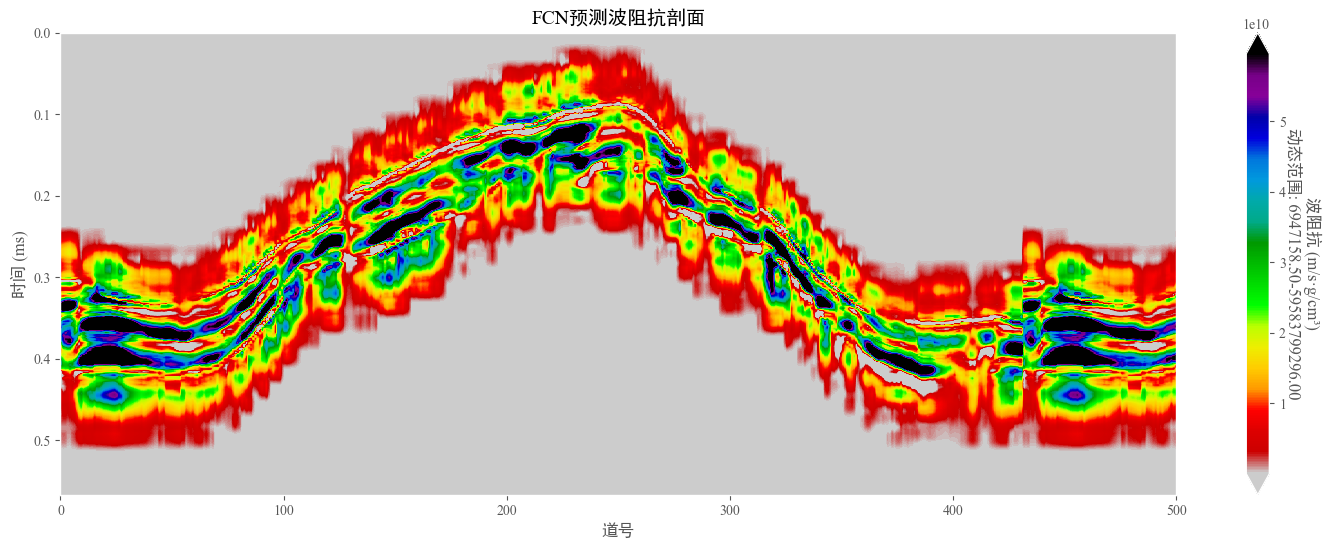


预测统计:
形状: (500, 568) (道数 × 采样点数)
最小值: -48253411328.00
最大值: 160335282176.00
平均值: 7372520960.00


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FCN().to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# 添加梯度裁剪
nn.utils.clip_grad_norm_(model.parameters(), 1.0)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

# 数据加载器
train_dataset = torch.utils.data.TensorDataset(trainX, trainImp)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
metrics = {
    'train_loss': [], 'val_loss': [],
    'train_pcc': [], 'val_pcc': [],
    'train_r2': [], 'val_r2': []
}

best_val_loss = float('inf')
early_stop_counter = 0

def compute_metrics(pred, true):
    pred = pred.detach().cpu().numpy()
    true = true.detach().cpu().numpy()
    pcc = np.corrcoef(pred.ravel(), true.ravel())[0,1]
    r2 = r2_score(true.ravel(), pred.ravel())
    return pcc, r2

SEISMIC_PATH = r"C:\Users\ZYH\Desktop\python_code\Marmousi2\data\1270-2199_DR_J3k.sgy"
MODEL_PATH = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\model_save\best_models\ma2_1\FCN_20Hz_model_epoch102_loss0_0002.pth'
NORM_PARAMS_PATH = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\norm_params.json'
OUTPUT_DIR = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\out_image\ma_true'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def load_data_with_metadata(path):
    """加载地震数据并获取元数据"""
    with segyio.open(path, "r", ignore_geometry=True, strict=False) as f:
        seismic = np.stack([np.copy(f.trace[i]) for i in range(500)])
        dt = f.bin[segyio.BinField.Interval] * 1e-6
        return seismic, dt



def load_normalization_params():
    """加载归一化参数"""
    with open(NORM_PARAMS_PATH) as f:
        params = json.load(f)
    return (
        params['s_min'], params['s_max'],
        params['imp_min'], params['imp_max']
    )

# ****************** 预处理函数 ******************
def preprocess(seismic, s_min, s_max):
    """数据标准化"""
    return (seismic - s_min) / (s_max - s_min)

def postprocess(prediction, imp_min, imp_max):
    """反归一化"""
    return prediction * (imp_max - imp_min) + imp_min

# ****************** 主预测函数 ******************
def predict_full_section():

    
    # 加载参数
    s_min, s_max, imp_min, imp_max = load_normalization_params()

    # 固定波阻抗参数（注意数值顺序已交换）
    imp_min = 6857730.0  # 实际最小值
    imp_max = 9825480.0  # 实际最大值
    
    
    # 加载地震数据
    seismic_raw, dt = load_data_with_metadata(SEISMIC_PATH)
    
    # 预处理
    seismic_norm = preprocess(seismic_raw, s_min, s_max)
    

    
    # 输出验证
    print(f"地震数据范围: {s_min:.2f} - {s_max:.2f} (自动计算)")
    print(f"波阻抗范围: {imp_min:.2f} - {imp_max:.2f} (固定参数)")
    

    # 转换为张量
    input_tensor = torch.FloatTensor(seismic_norm).unsqueeze(1).to(device)
    
    # 初始化模型
    model = FCN().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    model.eval()
    
    # 预测
    with torch.no_grad():
        prediction_norm = model(input_tensor).cpu().numpy().squeeze()
    
    return postprocess(prediction_norm, imp_min, imp_max), dt

# ****************** 可视化函数 ******************
def visualize_results(prediction, dt):
    """绘制波阻抗剖面"""
    n_samples = prediction.shape[1]
    time_axis = np.arange(n_samples) * dt 

    # 改进1：基于数据分布的动态范围计算
    # 使用98%百分位数避免极端值影响
    vmin = np.percentile(prediction, 2)  # 取2%低值作为下限
    vmax = np.percentile(prediction, 98) # 取98%高值作为上限
    
    # 改进2：添加颜色范围标注
    plt.figure(figsize=(18, 6))
    im = plt.imshow(prediction.T, 
                    aspect='auto',
                    cmap='nipy_spectral_r',
                    extent=[0, prediction.shape[0], time_axis[-1], time_axis[0]],
                    origin='upper',
                    vmin=vmin, 
                    vmax=vmax)
    
    # 改进3：在colorbar显示统计值
    cbar = plt.colorbar(im, extend='both')
    cbar.set_label('波阻抗 (m/s·g/cm³)\n动态范围: %.2f-%.2f'%(vmin, vmax), 
                  rotation=270, labelpad=25)
    
    # 其余保持原逻辑
    plt.xlabel('道号', fontsize=12)
    plt.ylabel('时间 (ms)', fontsize=12)
    plt.title('FCN预测波阻抗剖面', fontsize=14)

    plt.grid(False) # 保持网格关闭
    
    output_path = os.path.join(OUTPUT_DIR, 'impedance_003_model2.png')
    plt.savefig(output_path, dpi=600, bbox_inches='tight', format='png')
    plt.show()
    plt.close()



# ****************** 执行预测 ******************
if __name__ == '__main__':
    prediction, dt = predict_full_section()
    visualize_results(prediction, dt)
    
    # 打印统计信息
    print("\n预测统计:") 
    print(f"形状: {prediction.shape} (道数 × 采样点数)") 
    print(f"最小值: {np.min(prediction):.2f}")
    print(f"最大值: {np.max(prediction):.2f}")
    print(f"平均值: {np.mean(prediction):.2f}")


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FCN().to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# 添加梯度裁剪
nn.utils.clip_grad_norm_(model.parameters(), 1.0)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

# 数据加载器
train_dataset = torch.utils.data.TensorDataset(trainX, trainImp)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
metrics = {
    'train_loss': [], 'val_loss': [],
    'train_pcc': [], 'val_pcc': [],
    'train_r2': [], 'val_r2': []
}

best_val_loss = float('inf')
early_stop_counter = 0

def compute_metrics(pred, true):
    pred = pred.detach().cpu().numpy()
    true = true.detach().cpu().numpy()
    pcc = np.corrcoef(pred.ravel(), true.ravel())[0,1]
    r2 = r2_score(true.ravel(), pred.ravel())
    return pcc, r2

SEISMIC_PATH = r"C:\Users\ZYH\Desktop\python_code\Marmousi2\data\1270-2199_DR_J3k.sgy"
MODEL_PATH = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\model_save\best_models\ma2_1\FCN_20Hz_model_epoch102_loss0_0002.pth'
NORM_PARAMS_PATH = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\norm_params.json'
OUTPUT_DIR = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\out_image\ma_true'
os.makedirs(OUTPUT_DIR, exist_ok=True)


def load_data_with_metadata(path):
    """加载地震数据并计算极值"""
    with segyio.open(path, "r", ignore_geometry=True, strict=False) as f:
        # 加载前500道作为样本计算范围
        sample_data = np.stack([np.copy(f.trace[i]) for i in range(500)])
        s_min, s_max = np.min(sample_data), np.max(sample_data)
        
        # 加载完整数据
        seismic = np.stack([np.copy(f.trace[i]) for i in range(len(f.trace))])
        dt = f.bin[segyio.BinField.Interval] * 1e-6  # 转换为ms
        return seismic, dt, s_min, s_max  # 新增返回极值



def load_normalization_params():
    """加载归一化参数"""
    with open(NORM_PARAMS_PATH) as f:
        params = json.load(f)
    return (
        params['s_min'], params['s_max'],
        params['imp_min'], params['imp_max']
    )

# ****************** 预处理函数 ******************
# 修改预处理函数
def preprocess(seismic, s_min, s_max):
    """数据标准化到[0,1]范围"""
    return (seismic - s_min) / (s_max - s_min)

def postprocess(prediction, imp_min, imp_max):
    """反归一化到固定波阻抗范围"""
    return prediction * (imp_max - imp_min) + imp_min

# ****************** 主预测函数 ******************
def predict_full_section():
    # 加载数据并获取极值（正确解包4个返回值）
    seismic_raw, dt, s_min, s_max = load_data_with_metadata(SEISMIC_PATH)
    
    # 固定波阻抗参数（直接使用物理范围）
    imp_min = 6857730.0
    imp_max = 9825480.0
    
    # 预处理验证
    print(f"地震数据范围: {s_min:.2f} - {s_max:.2f} (自动计算)")
    print(f"波阻抗范围: {imp_min:.2f} - {imp_max:.2f} (固定参数)")
    
    # 预处理（使用当前文件的s_min/s_max）
    seismic_norm = preprocess(seismic_raw, s_min, s_max)
    
    # 转换为张量
    input_tensor = torch.FloatTensor(seismic_norm).unsqueeze(1).to(device)
    
    # 初始化模型
    model = FCN().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    model.eval()
    
    # 预测
    with torch.no_grad():
        prediction_norm = model(input_tensor).cpu().numpy().squeeze()
    
    return postprocess(prediction_norm, imp_min, imp_max), dt

# ****************** 可视化函数 ******************
def visualize_results(prediction, dt):
    """绘制波阻抗剖面"""
    n_samples = prediction.shape[1]
    time_axis = np.arange(n_samples) * dt 

    # 改进1：基于数据分布的动态范围计算
    # 使用98%百分位数避免极端值影响
    vmin = np.percentile(prediction, 2)  # 取2%低值作为下限
    vmax = np.percentile(prediction, 98) # 取98%高值作为上限
    
    # 改进2：添加颜色范围标注
    plt.figure(figsize=(18, 6))
    im = plt.imshow(prediction.T, 
                    aspect='auto',
                    cmap='nipy_spectral_r',
                    extent=[0, prediction.shape[0], time_axis[-1], time_axis[0]],
                    origin='upper',
                    vmin=vmin, 
                    vmax=vmax)
    
    # 改进3：在colorbar显示统计值
    cbar = plt.colorbar(im, extend='both')
    cbar.set_label('波阻抗 (m/s·g/cm³)\n动态范围: %.2f-%.2f'%(vmin, vmax), 
                  rotation=270, labelpad=25)
    
    # 其余保持原逻辑
    plt.xlabel('道号', fontsize=12)
    plt.ylabel('时间 (ms)', fontsize=12)
    plt.title('FCN预测波阻抗剖面', fontsize=14)

    plt.grid(False) # 保持网格关闭
    
    output_path = os.path.join(OUTPUT_DIR, 'impedance_003_model2.png')
    plt.savefig(output_path, dpi=600, bbox_inches='tight', format='png')
    plt.show()
    plt.close()



# ****************** 执行预测 ******************
if __name__ == '__main__':
    prediction, dt = predict_full_section()
    visualize_results(prediction, dt)
    
    # 打印统计信息
    print("\n预测统计:") 
    print(f"形状: {prediction.shape} (道数 × 采样点数)") 
    print(f"最小值: {np.min(prediction):.2f}")
    print(f"最大值: {np.max(prediction):.2f}")
    print(f"平均值: {np.mean(prediction):.2f}")


地震数据范围: -26545.30 - 20982.43 (自动计算)
波阻抗范围: 6857730.00 - 9825480.00 (固定参数)


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 14570390528 bytes.

使用设备: cpu
正在从 C:\Users\ZYH\Desktop\python_code\Marmousi2\data\norm_params.json 加载训练时的归一化参数...
成功加载训练归一化参数:
  训练地震数据范围 (s_min, s_max): -1.1593, 1.0908
  训练波阻抗范围 (imp_min, imp_max): 1515.00, 12346.90
正在加载 SEGY 文件: C:\Users\ZYH\Desktop\python_code\Marmousi2\data\1270-2199_DR_J3k.sgy
文件信息: 500 道, 568 采样点/道
SEGY 加载完成: 形状=(500, 568), 采样间隔 dt=1.00 ms
正在使用训练参数 (s_min=-1.1593, s_max=1.0908) 对当前地震数据进行归一化...
使用训练参数归一化后，当前地震数据的实际范围: Min=-11796.9482, Max=9325.6836
转换为模型输入张量，形状: torch.Size([500, 1, 568])
正在加载预训练模型: C:\Users\ZYH\Desktop\python_code\Marmousi2\data\model_save\best_models\ma2_1\FCN_20Hz_model_epoch102_loss0_0002.pth
使用 weights_only=True 加载模型状态字典。
模型加载成功并设置为评估模式。
正在使用模型进行预测...
模型输出 (归一化阻抗) 形状: (500, 568)
模型输出 (归一化阻抗) 实际范围: Min=-16261.5713, Max=54023.5547
正在使用训练参数 (imp_min=1515.00, imp_max=12346.90) 进行反归一化...
反归一化完成 (未使用裁剪)。

最终预测统计 (使用训练参数反归一化, 未经裁剪):
形状: (500, 568) (道数 × 采样点数)
最小值: -176142199.05
最大值: 585179257.02
平均值: 26885221.98
中位数: 7755.55
开始绘制结果...
绘图颜色范围使用数据 2%-98% 百分位数: vmin=1841.

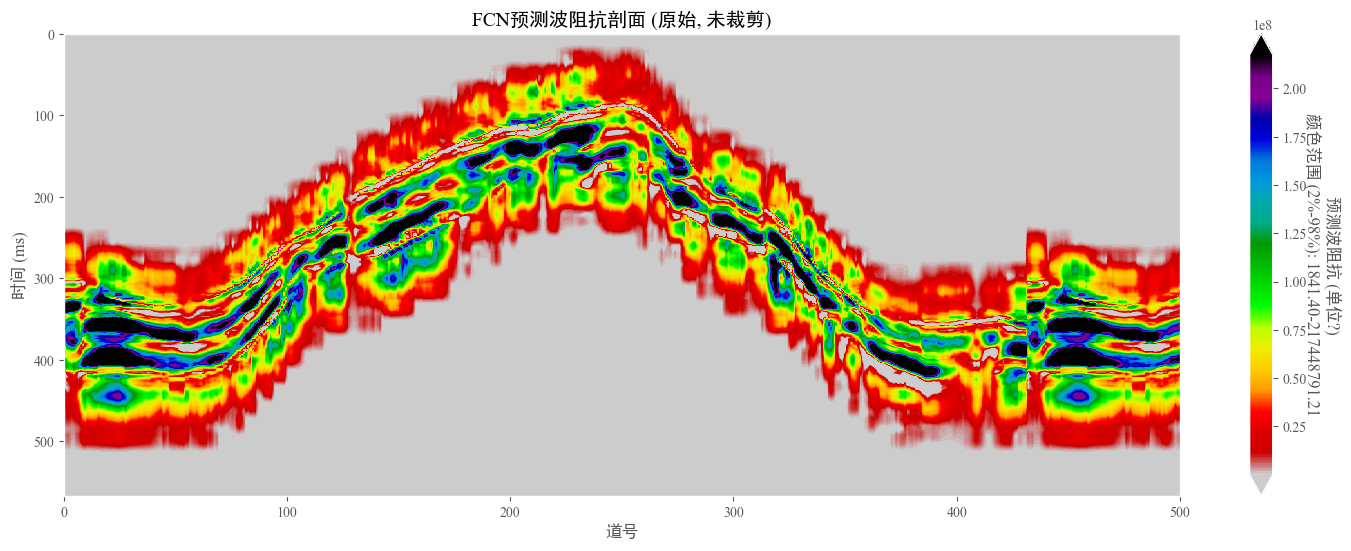

绘图完成。

--- 评估预测结果与目标范围 ---
用户指定的目标范围: [6857730.00, 9825480.00]
结论: 预测结果部分超出了用户指定的目标范围。
  有 64.57% 的值低于目标下限 6857730.00
  有 33.74% 的值高于目标上限 9825480.00
可能原因及建议:
  1. **归一化策略匹配是关键:** 确保预测时使用的参数与训练时完全一致。
  2. **模型泛化能力:** 模型在新数据上可能表现不佳，导致预测值偏离。
  3. **目标范围设定:** 检查用户指定的目标范围 `[6857730.0, 9825480.0]` 是否真的适用于当前数据。
  4. **训练问题:** 检查训练过程和模型最后一层是否有 Sigmoid 等约束（如果目标是[0,1]）。

如果确认归一化参数正确，且确实需要将结果约束在目标范围内，
可以在 `visualize_results` 之后或之前添加裁剪步骤:


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import segyio
from pathlib import Path
# from torch.autograd import Variable # Variable 已弃用
# from sklearn.model_selection import train_test_split # 未在此脚本中使用
from sklearn.metrics import r2_score # 未在此脚本中使用，但可能在训练脚本中用到
import torch.nn.functional as F
import traceback # 用于打印详细错误信息


# ---------- 路径配置 ----------
SEISMIC_PATH = r"C:\Users\ZYH\Desktop\python_code\Marmousi2\data\1270-2199_DR_J3k.sgy"
MODEL_PATH = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\model_save\best_models\ma2_1\FCN_20Hz_model_epoch102_loss0_0002.pth'
# 这个文件现在至关重要，必须包含训练时的 s_min, s_max, imp_min, imp_max
NORM_PARAMS_PATH = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\norm_params.json'
OUTPUT_DIR = r'C:\Users\ZYH\Desktop\python_code\Marmousi2\data\out_image\ma_true'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------- 设备配置 ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# ---------- 数据加载函数 ----------
def load_data_with_metadata(path):
    """加载地震数据并获取元数据"""
    print(f"正在加载 SEGY 文件: {path}")
    try:
        with segyio.open(path, "r", ignore_geometry=True, strict=False) as f:
            num_traces_to_load = 500 # 可以修改需要加载的道数
            actual_traces = min(num_traces_to_load, f.tracecount)
            if f.tracecount < num_traces_to_load:
                print(f"警告: 文件道数 ({f.tracecount}) 少于请求的道数 ({num_traces_to_load})。将加载所有 {actual_traces} 道。")
            if actual_traces == 0:
                 raise ValueError("SEGY 文件不包含任何地震道。")

            # 检查样本数是否为0
            if f.samples is None or len(f.samples) == 0:
                raise ValueError("SEGY 文件样本数无效或为零。")
            print(f"文件信息: {actual_traces} 道, {len(f.samples)} 采样点/道")

            seismic = np.stack([np.copy(f.trace[i]) for i in range(actual_traces)])

            dt_micro = f.bin[segyio.BinField.Interval]
            if dt_micro <= 0:
                 print("警告: SEGY 文件头中的采样间隔无效或为零，将使用默认值 0.004s (4ms)。")
                 dt = 0.004 # 设置一个默认值，单位：秒
            else:
                 dt = dt_micro * 1e-6 # 从微秒转换为秒

            print(f"SEGY 加载完成: 形状={seismic.shape}, 采样间隔 dt={dt*1000:.2f} ms")
            return seismic.astype(np.float32), dt # 确保数据类型为 float32
    except FileNotFoundError:
        print(f"错误: 找不到 SEGY 文件: {path}")
        raise
    except Exception as e:
        print(f"加载 SEGY 文件失败: {e}")
        traceback.print_exc() # 打印详细错误信息
        raise

# ****************** 加载训练参数函数 ******************
def load_training_normalization_params(path):
    """加载训练时使用的归一化参数"""
    print(f"正在从 {path} 加载训练时的归一化参数...")
    try:
        with open(path, 'r') as f:
            params = json.load(f)
        # 确保所有需要的键都存在
        required_keys = ['s_min', 's_max', 'imp_min', 'imp_max']
        missing_keys = [key for key in required_keys if key not in params]
        if missing_keys:
            raise ValueError(f"JSON 文件 {path} 缺少必要的归一化参数键: {', '.join(missing_keys)}")

        s_min = float(params['s_min'])
        s_max = float(params['s_max'])
        imp_min = float(params['imp_min'])
        imp_max = float(params['imp_max'])

        print("成功加载训练归一化参数:")
        print(f"  训练地震数据范围 (s_min, s_max): {s_min:.4f}, {s_max:.4f}")
        print(f"  训练波阻抗范围 (imp_min, imp_max): {imp_min:.2f}, {imp_max:.2f}")
        return s_min, s_max, imp_min, imp_max
    except FileNotFoundError:
        print(f"错误: 找不到归一化参数文件: {path}")
        raise
    except json.JSONDecodeError:
        print(f"错误: 无法解析 JSON 文件: {path}")
        raise
    except ValueError as ve: # 捕获我们自己抛出的 ValueError
        print(f"错误: {ve}")
        raise
    except Exception as e:
        print(f"加载训练归一化参数时发生未知错误: {e}")
        traceback.print_exc()
        raise

# ****************** 预处理函数 (使用传入的 min/max) ******************
def preprocess(seismic, s_min, s_max):
    """使用指定的 min/max 将数据归一化到 [0, 1] (理论上)"""
    if s_max == s_min:
        print("警告: 归一化参数中 s_max 等于 s_min，无法归一化。将返回零数组。")
        return np.zeros_like(seismic, dtype=np.float32)
    # 使用 float64 进行计算以提高精度
    normalized = (seismic.astype(np.float64) - s_min) / (s_max - s_min)
    # 对于预测，即使理论上应该在 [0, 1]，也不强制裁剪，让模型处理实际输入
    return normalized.astype(np.float32) # 返回模型期望的 float32

# ****************** 后处理函数 (使用传入的 min/max) ******************
def postprocess(prediction_norm, imp_min, imp_max):
    """使用指定的 min/max 将模型输出反归一化到物理范围"""
    # 使用 float64 进行计算
    denormalized = prediction_norm.astype(np.float64) * (imp_max - imp_min) + imp_min
    return denormalized # 可以保持 float64 或转回 float32

# ****************** 主预测函数 (修改为使用训练参数, 不裁剪) ******************
def predict_full_section():

    # --- 1. 加载训练时使用的归一化参数 ---
    try:
        s_min_train, s_max_train, imp_min_train, imp_max_train = load_training_normalization_params(NORM_PARAMS_PATH)
    except Exception:
        print("错误: 无法加载或验证训练归一化参数，预测中止。")
        return None, None # 返回 None 表示失败

    # --- 2. 加载新的地震数据 ---
    try:
        seismic_raw, dt = load_data_with_metadata(SEISMIC_PATH)
    except Exception:
        print("错误: 加载地震数据失败，预测中止。")
        return None, None # 返回 None 表示失败

    # --- 3. 使用训练时的 s_min, s_max 进行预处理 ---
    print(f"正在使用训练参数 (s_min={s_min_train:.4f}, s_max={s_max_train:.4f}) 对当前地震数据进行归一化...")
    seismic_norm = preprocess(seismic_raw, s_min_train, s_max_train)
    # 打印归一化后数据的实际范围（它可能不严格在 [0, 1] 内，这取决于新数据和训练参数的关系）
    print(f"使用训练参数归一化后，当前地震数据的实际范围: Min={np.min(seismic_norm):.4f}, Max={np.max(seismic_norm):.4f}")
    # -----------------------------------------------------

    # --- 4. 准备模型输入 ---
    # 形状: (N=道数, C=1, L=采样点数)
    input_tensor = torch.from_numpy(seismic_norm).unsqueeze(1).to(device)
    print(f"转换为模型输入张量，形状: {input_tensor.shape}")
    # -----------------------

    # --- 5. 加载预训练模型 ---
    print(f"正在加载预训练模型: {MODEL_PATH}")
    # !!! 确保这里的 FCN() 与模型文件匹配 !!!
    model = FCN().to(device)
    try:
        # 优先使用 weights_only=True (PyTorch 1.13+)
        if hasattr(torch, 'load') and 'weights_only' in torch.load.__code__.co_varnames:
             state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
             print("使用 weights_only=True 加载模型状态字典。")
        else:
             state_dict = torch.load(MODEL_PATH, map_location=device)
             print("未使用 weights_only 加载模型状态字典。")
        model.load_state_dict(state_dict)
        model.eval() # 设置为评估模式
        print("模型加载成功并设置为评估模式。")
    except FileNotFoundError:
        print(f"错误: 找不到模型文件: {MODEL_PATH}")
        raise
    except Exception as e:
        print(f"加载模型状态字典失败: {e}")
        traceback.print_exc()
        raise
    # -------------------------

    # --- 6. 执行预测 ---
    print("正在使用模型进行预测...")
    with torch.no_grad(): # 关闭梯度计算以节省内存和加速
        prediction_norm_tensor = model(input_tensor)
    # 移回 CPU, 去掉通道维度 (假设输出通道为1), 转为 NumPy
    prediction_norm = prediction_norm_tensor.cpu().squeeze(1).numpy()
    print(f"模型输出 (归一化阻抗) 形状: {prediction_norm.shape}")
    # 打印模型输出的范围，检查是否接近 [0, 1] 或训练时的归一化目标范围
    print(f"模型输出 (归一化阻抗) 实际范围: Min={np.min(prediction_norm):.4f}, Max={np.max(prediction_norm):.4f}")
    # --------------------

    # --- 7. 使用训练时的 imp_min, imp_max 进行反归一化 ---
    print(f"正在使用训练参数 (imp_min={imp_min_train:.2f}, imp_max={imp_max_train:.2f}) 进行反归一化...")
    prediction_final_unclipped = postprocess(prediction_norm, imp_min_train, imp_max_train)
    print("反归一化完成 (未使用裁剪)。")
    # -----------------------------------------------------

    # --- 8. 返回 *未经裁剪* 的最终结果和时间间隔 ---
    return prediction_final_unclipped, dt

# ****************** 可视化函数 ******************
def visualize_results(prediction, dt, title_suffix=""):
    """绘制波阻抗剖面"""
    print("开始绘制结果...")
    if prediction is None or dt is None:
        print("无有效预测结果或时间间隔，无法绘图。")
        return

    n_traces, n_samples = prediction.shape
    time_axis_ms = np.arange(n_samples) * dt * 1000 # 转换为毫秒

    # --- 颜色范围设定 ---
    # 选择1: 使用实际数据的百分位数 (观察真实分布)
    vmin_plot = np.percentile(prediction, 2)
    vmax_plot = np.percentile(prediction, 98)
    extend_mode = 'both' # 因为用了百分位，可能超出
    color_label = f'预测波阻抗 (单位?)\n颜色范围 (2%-98%): {vmin_plot:.2f}-{vmax_plot:.2f}'
    print(f"绘图颜色范围使用数据 2%-98% 百分位数: vmin={vmin_plot:.2f}, vmax={vmax_plot:.2f}")

    # 选择2: 使用训练时的 imp_min, imp_max (观察与训练范围的对比)
    # try:
    #     _, _, imp_min_train_vis, imp_max_train_vis = load_training_normalization_params(NORM_PARAMS_PATH)
    #     vmin_plot = imp_min_train_vis
    #     vmax_plot = imp_max_train_vis
    #     extend_mode = 'neither' # 或 'both' 如果预测可能超出训练范围
    #     color_label = f'预测波阻抗 (单位?)\n颜色范围 (训练范围): {vmin_plot:.2f}-{vmax_plot:.2f}'
    #     print(f"绘图颜色范围使用训练阻抗范围: vmin={vmin_plot:.2f}, vmax={vmax_plot:.2f}")
    # except Exception:
    #     print("无法加载训练阻抗范围用于绘图，将使用百分位数。")
    #     vmin_plot = np.percentile(prediction, 2)
    #     vmax_plot = np.percentile(prediction, 98)
    #     extend_mode = 'both'
    #     color_label = f'预测波阻抗 (单位?)\n颜色范围 (2%-98%): {vmin_plot:.2f}-{vmax_plot:.2f}'

    plt.figure(figsize=(18, 6))
    im = plt.imshow(prediction.T, # 转置使得道号是 X 轴，时间是 Y 轴
                    aspect='auto',
                    cmap='nipy_spectral_r', # 可以尝试 'jet', 'rainbow', 'seismic' 等
                    extent=[0, n_traces, time_axis_ms[-1], time_axis_ms[0]], # x_min, x_max, y_max, y_min
                    origin='upper', # 时间 0 在顶部
                    vmin=vmin_plot,
                    vmax=vmax_plot)

    cbar = plt.colorbar(im, extend=extend_mode)
    cbar.set_label(color_label, rotation=270, labelpad=25)

    plt.xlabel('道号', fontsize=12)
    plt.ylabel('时间 (ms)', fontsize=12)
    base_title = 'FCN预测波阻抗剖面'
    plt.title(f'{base_title}{title_suffix}', fontsize=14)

    plt.grid(False)

    # 保存图像
    output_filename = f'predicted_impedance_profile_unclipped.png'
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    try:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', format='png')
        print(f"结果图像已保存至: {output_path}")
    except Exception as e:
        print(f"保存图像失败: {e}")
    plt.show()
    plt.close()
    print("绘图完成。")

# ****************** 主执行块 ******************
if __name__ == '__main__':
    try:
        # 执行预测 (使用训练参数反归一化, 不裁剪)
        prediction_unclipped, dt = predict_full_section()

        if prediction_unclipped is not None:
            # --- 打印 *未经裁剪* 的统计信息 ---
            print("\n最终预测统计 (使用训练参数反归一化, 未经裁剪):")
            print(f"形状: {prediction_unclipped.shape} (道数 × 采样点数)")
            min_pred = np.min(prediction_unclipped)
            max_pred = np.max(prediction_unclipped)
            mean_pred = np.mean(prediction_unclipped)
            median_pred = np.median(prediction_unclipped)
            print(f"最小值: {min_pred:.2f}")
            print(f"最大值: {max_pred:.2f}")
            print(f"平均值: {mean_pred:.2f}")
            print(f"中位数: {median_pred:.2f}")

            # --- 可视化未经裁剪的结果 ---
            visualize_results(prediction_unclipped, dt, title_suffix=" (原始, 未裁剪)")

            # --- 评估与目标范围的对比 ---
            print("\n--- 评估预测结果与目标范围 ---")
            target_min = 6857730.0 # 你之前设定的目标下限
            target_max = 9825480.0 # 你之前设定的目标上限
            print(f"用户指定的目标范围: [{target_min:.2f}, {target_max:.2f}]")

            if min_pred >= target_min and max_pred <= target_max:
                print("结论: 预测结果完全落在用户指定的目标范围内。之前的裁剪是不必要的。")
            elif max_pred < target_min or min_pred > target_max:
                 print("警告: 预测结果完全在目标范围之外！请检查：")
                 print("  1. `norm_params.json` 中的训练参数是否正确？")
                 print("  2. 加载的模型是否与参数对应？")
                 print("  3. FCN 模型定义是否正确？")
            else:
                print("结论: 预测结果部分超出了用户指定的目标范围。")
                print(f"  有 {(prediction_unclipped < target_min).sum() / prediction_unclipped.size * 100:.2f}% 的值低于目标下限 {target_min:.2f}")
                print(f"  有 {(prediction_unclipped > target_max).sum() / prediction_unclipped.size * 100:.2f}% 的值高于目标上限 {target_max:.2f}")
                print("可能原因及建议:")
                print("  1. **归一化策略匹配是关键:** 确保预测时使用的参数与训练时完全一致。")
                print("  2. **模型泛化能力:** 模型在新数据上可能表现不佳，导致预测值偏离。")
                print("  3. **目标范围设定:** 检查用户指定的目标范围 `[6857730.0, 9825480.0]` 是否真的适用于当前数据。")
                print("  4. **训练问题:** 检查训练过程和模型最后一层是否有 Sigmoid 等约束（如果目标是[0,1]）。")
                print("\n如果确认归一化参数正确，且确实需要将结果约束在目标范围内，")
                print("可以在 `visualize_results` 之后或之前添加裁剪步骤:")
                # --- 可选的裁剪步骤 ---
                # print("\n进行裁剪以强制约束在目标范围内...")
                # prediction_clipped = np.clip(prediction_unclipped, target_min, target_max)
                # print("裁剪后的统计:")
                # print(f"  最小值 (裁剪后): {np.min(prediction_clipped):.2f}")
                # print(f"  最大值 (裁剪后): {np.max(prediction_clipped):.2f}")
                # print(f"  平均值 (裁剪后): {np.mean(prediction_clipped):.2f}")
                # print(f"  中位数 (裁剪后): {np.median(prediction_clipped):.2f}")
                # # 可以选择再次可视化裁剪后的结果
                # visualize_results(prediction_clipped, dt, title_suffix=" (强制裁剪后)")
                # ----------------------
        else:
            print("\n预测未能成功执行，无法进行后续处理。")

    except Exception as e:
        print(f"\n!!! 程序主执行过程中发生严重错误 !!!")
        print(f"错误类型: {type(e).__name__}")
        print(f"错误信息: {e}")
        traceback.print_exc() # 打印详细的回溯信息

